# Słoczyński (2022): *When Should We (Not) Interpret Linear IV Estimands as LATE?*

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/afrtrivi1120/causal-inference-papers-explainer/blob/master/papers/iv/sloczynski-linear-iv-late/simulation.ipynb)

> **Colab users**: after clicking the badge, pick *Runtime → Change runtime type → R* once per session, then *Run all*.

See this folder's `README.md` for the 12-section explainer. This notebook is its runnable companion.

**What this simulation shows.** The everyday IV recipe — `ivreg(Y ~ D + X | Z + X)` — can put a *negative weight* on one stratum's treatment effect and therefore return an estimate near zero (or of the wrong sign) even when the true treatment effect is 1.0 in every stratum. This happens whenever different covariate subgroups respond to the instrument in opposite directions (weak monotonicity, not strong monotonicity). A per-stratum Wald aggregated by estimated mover mass `|ω̂(X)|` — which by Słoczyński's eq. 8 + Lemma 2.1(ii) targets the population LATE under WM — recovers the truth. (Note: this τ_LATE-targeting estimator is closely related to but not identical to Angrist-Imbens's interacted 2SLS, which by Theorem 3.2 weights conditional LATEs by `π(X)² · Var(Z|X)` rather than `π(X)`.)

**DGP at a glance.** Two strata `X ∈ {0, 1}` with equal population shares `0.5`. The instrument `Z` is randomly assigned with probability `0.5` in both strata.

| Stratum | Compliance mix | Conditional first stage `ω(X)` | Stratum LATE `τ(X)` |
|---|---|---|---|
| `X = 0` | 50% compliers, 50% never-takers | +0.5 (positive) | 1.0 |
| `X = 1` | 50% defiers, 50% always-takers | −0.5 (negative) | 1.0 |

Because `ω(0) > 0` and `ω(1) < 0`, strong monotonicity (SM) fails but weak monotonicity (WM) holds. The noninteracted linear IV imposes a single first-stage slope and must average `+0.5` and `−0.5` — ending up near zero — so its implied weights on `τ(0)` and `τ(1)` have opposite signs. With both stratum LATEs equal to 1, the noninteracted estimate is pulled near 0. The population LATE — the `|ω̂(X)|`-weighted average of `τ(X)` — equals **1.0**.

This is a single-draw illustration at `N = 20000` so the contrast is sharp without averaging across replications.

## Setup

In [1]:
if (!requireNamespace('AER', quietly = TRUE)) install.packages('AER', quiet = TRUE)

suppressPackageStartupMessages({
  library(tidyverse)
  library(AER)
})
set.seed(20260421)

cat(sprintf('R          %s\n', paste(R.version$major, R.version$minor, sep = '.')))
cat(sprintf('tidyverse  %s\n', packageVersion('tidyverse')))
cat(sprintf('AER        %s\n', packageVersion('AER')))

R          4.5.3


tidyverse  2.0.0


AER        1.2.16


## Parameters and true population LATE

In [2]:
N <- 20000   # single draw, large enough that sampling noise is small

# Population share of each stratum.
pX <- 0.5

# Instrument randomized with equal probability in both strata.
pZ_X0 <- 0.5
pZ_X1 <- 0.5

# Compliance-type mix per stratum.
# Stratum X=0: compliers + never-takers  =>  first stage omega(0) = +0.5
# Stratum X=1: defiers  + always-takers  =>  first stage omega(1) = -0.5
complier_share_X0 <- 0.5   # P(complier | X=0)
defier_share_X1   <- 0.5   # P(defier   | X=1)

# Conditional first stages (population truth).
omega_X0 <- +complier_share_X0   # E[D(1)-D(0)|X=0] = +0.5
omega_X1 <- -defier_share_X1     # E[D(1)-D(0)|X=1] = -0.5

# Constant stratum LATEs.
tau_X0 <- 1.0
tau_X1 <- 1.0

# Mover mass per stratum: pi(x) = |omega(x)|
pi_X0 <- abs(omega_X0)   # 0.5
pi_X1 <- abs(omega_X1)   # 0.5

# Population LATE = E[pi(X)*tau(X)] / E[pi(X)]  (eq. 8 of the paper)
true_LATE <- (pX * pi_X0 * tau_X0 + pX * pi_X1 * tau_X1) /
             (pX * pi_X0 + pX * pi_X1)
cat(sprintf('Population LATE (true): %.3f\n', true_LATE))

Population LATE (true): 1.000


## DGP

In [3]:
# Draw strata and instrument.
X <- rbinom(N, 1, pX)
Z <- rbinom(N, 1, ifelse(X == 0, pZ_X0, pZ_X1))

# Draw compliance types within each stratum.
# Stratum X=0: compliers and never-takers only.
# Stratum X=1: defiers and always-takers only.
type <- character(N)
type[X == 0] <- sample(
  c('complier', 'never'),
  sum(X == 0),
  replace = TRUE,
  prob = c(complier_share_X0, 1 - complier_share_X0)
)
type[X == 1] <- sample(
  c('defier', 'always'),
  sum(X == 1),
  replace = TRUE,
  prob = c(defier_share_X1, 1 - defier_share_X1)
)

# Treatment from compliance type and instrument.
# Complier: D=1 iff Z=1; Defier: D=1 iff Z=0; Always: D=1; Never: D=0.
D <- case_when(
  type == 'complier' ~ as.integer(Z == 1),
  type == 'defier'   ~ as.integer(Z == 0),
  type == 'always'   ~ 1L,
  type == 'never'    ~ 0L
)

# Outcome: constant treatment effect of 1 in every stratum.
Y <- D * 1.0 + rnorm(N, 0, 1)

df <- tibble(Y, D, Z, X, type)

# Sanity check: empirical first stages should be close to ±0.5.
fs0 <- mean(df$D[df$X == 0 & df$Z == 1]) - mean(df$D[df$X == 0 & df$Z == 0])
fs1 <- mean(df$D[df$X == 1 & df$Z == 1]) - mean(df$D[df$X == 1 & df$Z == 0])
cat(sprintf('Estimated first stage:  omega_hat(X=0) = %+.4f,  omega_hat(X=1) = %+.4f\n', fs0, fs1))

Estimated first stage:  omega_hat(X=0) = +0.4994,  omega_hat(X=1) = -0.4955


## Two estimators

1. **Noninteracted linear IV** — `ivreg(Y ~ D + X | Z + X)`. The everyday recipe. Słoczyński's central result: under WM (opposite-sign first stages), this estimand puts a *negative* weight on one stratum's LATE.
2. **τ_LATE Wald (per stratum, pooled by `|ω̂(X)|`)** — a Wald ratio within each stratum, aggregated by estimated mover mass `π̂(x) = |ω̂(x)|`. By eq. 8 + Lemma 2.1(ii), this targets `τ_LATE` under WM. Note this is **not** the AI(1995) interacted 2SLS (β_2SLS): per Theorem 3.2, AI's 2SLS weights conditional LATEs by `π(X)² · Var(Z|X)`, not by `π(X)`. The per-stratum Wald is the cleaner pedagogical comparison; AI's 2SLS would also avoid negative weights but recover a different positively-weighted average.

In [4]:
# Estimator 1 — noninteracted linear IV.
fit_nonint <- AER::ivreg(Y ~ D + X | Z + X, data = df)
stopifnot('D' %in% names(coef(fit_nonint)))   # label-safe lookup per CLAUDE.md
est_nonint  <- unname(coef(fit_nonint)['D'])

# Estimator 2 — tau_LATE Wald: per-stratum Wald, aggregated by |omega_hat(x)| * P(X=x).
wald_stratum <- function(sub) {
  # beta(x) = [E[Y|Z=1,x] - E[Y|Z=0,x]] / [E[D|Z=1,x] - E[D|Z=0,x]]
  rf <- mean(sub$Y[sub$Z == 1]) - mean(sub$Y[sub$Z == 0])   # reduced form
  fs <- mean(sub$D[sub$Z == 1]) - mean(sub$D[sub$Z == 0])   # first stage
  list(beta = rf / fs, omega_hat = fs)
}

w0 <- wald_stratum(filter(df, X == 0))
w1 <- wald_stratum(filter(df, X == 1))

# Mover-mass weights: weight(x) = P(X=x) * |omega_hat(x)|.
mass0 <- (sum(df$X == 0) / N) * abs(w0$omega_hat)
mass1 <- (sum(df$X == 1) / N) * abs(w1$omega_hat)

est_ai <- (mass0 * w0$beta + mass1 * w1$beta) / (mass0 + mass1)

# Truth-vs-estimate comparison tibble.
result_tbl <- tibble(
  estimator    = c(
    'Truth (population LATE)',
    'Noninteracted linear IV  (Y ~ D + X | Z + X)',
    'tau_LATE Wald (per stratum, pooled by |omega_hat(X)|)'
  ),
  estimate     = c(true_LATE, est_nonint, est_ai),
  gap_vs_truth = c(0.0, est_nonint - true_LATE, est_ai - true_LATE)
)
print(result_tbl)

# A tibble: 3 × 3
  estimator                                             estimate gap_vs_truth
  <chr>                                                    <dbl>        <dbl>
1 Truth (population LATE)                                 1            0     
2 Noninteracted linear IV  (Y ~ D + X | Z + X)           -0.0257      -1.03  
3 tau_LATE Wald (per stratum, pooled by |omega_hat(X)|)   1.02         0.0179


## Implied weights of the noninteracted estimand

Słoczyński's decomposition (Section 3.2): the noninteracted linear IV estimand is a weighted average of conditional LATEs with weights proportional to `ω(x) · Var(Z|x) · P(X=x)`. With `Var(Z|x)` and `P(X=x)` equal across strata, the weights are proportional to `ω(x)` — positive for stratum 0, **negative** for stratum 1.

In [5]:
# Var(Z|x) = p_hat(Z=1|x) * (1 - p_hat(Z=1|x))
pZ_hat_X0 <- mean(df$Z[df$X == 0])
pZ_hat_X1 <- mean(df$Z[df$X == 1])
varZ_X0   <- pZ_hat_X0 * (1 - pZ_hat_X0)
varZ_X1   <- pZ_hat_X1 * (1 - pZ_hat_X1)
pX_X0     <- mean(df$X == 0)
pX_X1     <- mean(df$X == 1)

# Unnormalized weights: omega_hat(x) * Var(Z|x) * P(X=x).
wt_raw_X0 <- w0$omega_hat * varZ_X0 * pX_X0
wt_raw_X1 <- w1$omega_hat * varZ_X1 * pX_X1
tot_nonint <- wt_raw_X0 + wt_raw_X1

# Normalized noninteracted IV weights.
wt_nonint_X0 <- wt_raw_X0 / tot_nonint
wt_nonint_X1 <- wt_raw_X1 / tot_nonint

# Desired weights for tau_LATE: |omega_hat(x)| * P(X=x), normalized.
wt_ai_X0 <- mass0 / (mass0 + mass1)
wt_ai_X1 <- mass1 / (mass0 + mass1)

weights_tbl <- tibble(
  stratum       = c('X = 0', 'X = 1'),
  omega_hat     = c(w0$omega_hat, w1$omega_hat),
  wt_nonint_IV  = c(wt_nonint_X0, wt_nonint_X1),
  wt_ai_desired = c(wt_ai_X0, wt_ai_X1)
)
print(weights_tbl)

# A tibble: 2 × 4
  stratum omega_hat wt_nonint_IV wt_ai_desired
  <chr>       <dbl>        <dbl>         <dbl>
1 X = 0       0.499         43.3         0.506
2 X = 1      -0.495        -42.3         0.494


## Diagnostic plots

Two figures. The first shows the implied weights each estimand puts on the two strata's LATEs — the negative bar for stratum X=1 under noninteracted IV is the paper's signature result. The second shows the final estimates against the true LATE.

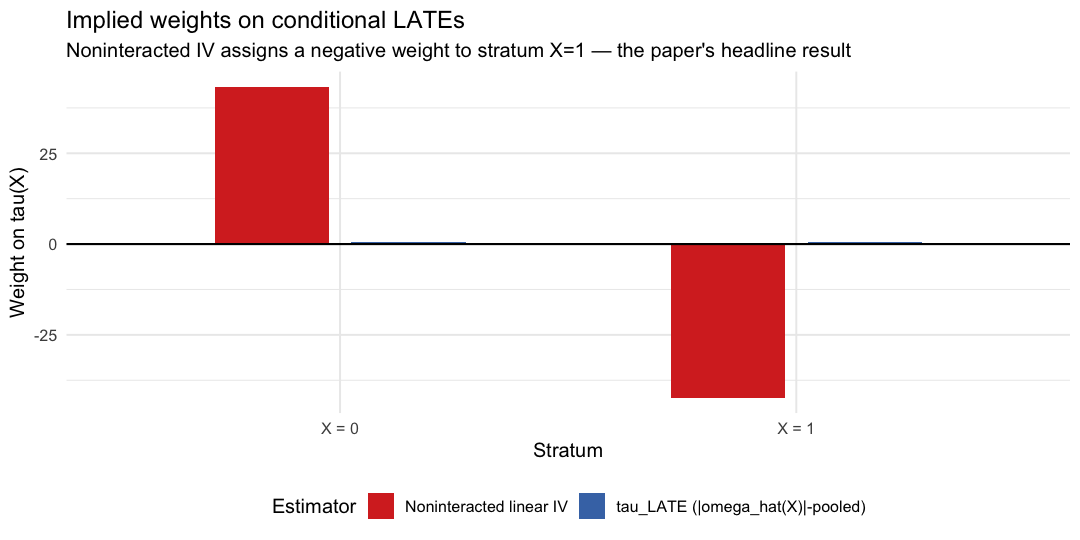

In [6]:
# Build long-format weight table for plotting.
weights_long <- weights_tbl |>
  select(stratum, wt_nonint_IV, wt_ai_desired) |>
  pivot_longer(
    cols      = c(wt_nonint_IV, wt_ai_desired),
    names_to  = 'estimator',
    values_to = 'weight'
  ) |>
  mutate(
    estimator = case_when(
      estimator == 'wt_nonint_IV'  ~ 'Noninteracted linear IV',
      estimator == 'wt_ai_desired' ~ 'tau_LATE (|omega_hat(X)|-pooled)'
    ),
    estimator = factor(
      estimator,
      levels = c('Noninteracted linear IV', 'tau_LATE (|omega_hat(X)|-pooled)')
    )
  )

options(repr.plot.width = 9, repr.plot.height = 4.5)

ggplot(weights_long, aes(stratum, weight, fill = estimator)) +
  geom_col(position = position_dodge(width = 0.6), width = 0.5) +
  geom_hline(yintercept = 0, linewidth = 0.6) +
  scale_fill_manual(
    values = c(
      'Noninteracted linear IV'           = '#d73027',
      'tau_LATE (|omega_hat(X)|-pooled)'  = '#4575b4'
    )
  ) +
  labs(
    title    = 'Implied weights on conditional LATEs',
    subtitle = "Noninteracted IV assigns a negative weight to stratum X=1 — the paper's headline result",
    x = 'Stratum', y = 'Weight on tau(X)', fill = 'Estimator'
  ) +
  theme_minimal(base_size = 12) +
  theme(legend.position = 'bottom')

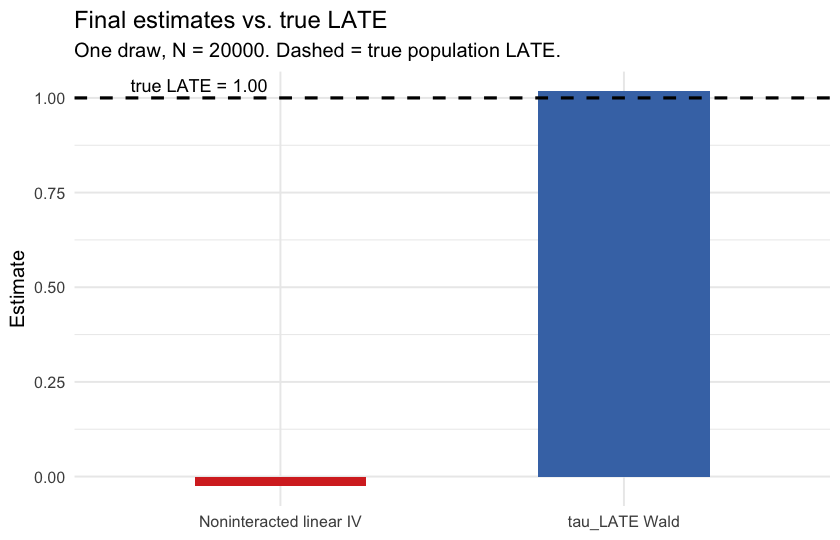

In [7]:
# Final estimates vs. true LATE.
est_df <- tibble(
  estimator = factor(
    c('Noninteracted linear IV', 'tau_LATE Wald'),
    levels = c('Noninteracted linear IV', 'tau_LATE Wald')
  ),
  estimate = c(est_nonint, est_ai)
)

options(repr.plot.width = 7, repr.plot.height = 4.5)

ggplot(est_df, aes(estimator, estimate, fill = estimator)) +
  geom_col(width = 0.5) +
  geom_hline(yintercept = true_LATE, linetype = 'dashed', linewidth = 0.9) +
  annotate(
    'text', x = 0.55, y = true_LATE,
    label = sprintf(' true LATE = %.2f', true_LATE),
    hjust = 0, vjust = -0.5, size = 3.8
  ) +
  scale_fill_manual(
    values = c(
      'Noninteracted linear IV' = '#d73027',
      'tau_LATE Wald'           = '#4575b4'
    )
  ) +
  labs(
    title    = 'Final estimates vs. true LATE',
    subtitle = sprintf('One draw, N = %d. Dashed = true population LATE.', N),
    x = NULL, y = 'Estimate'
  ) +
  theme_minimal(base_size = 12) +
  theme(legend.position = 'none')

## Punchline

When different covariate subgroups respond to the instrument in opposite directions — a positive first stage in stratum 0, a negative first stage in stratum 1 — the standard noninteracted linear IV specification forces a single average slope across both strata. The first-stage averaging of `+0.5` and `−0.5` produces an estimand that puts a **positive weight** on stratum 0's LATE and a **negative weight** on stratum 1's LATE. The first plot makes this sign flip unmistakable: stratum X=1's bar goes below zero under the noninteracted estimator, while the τ_LATE-targeting Wald keeps both weights positive at around 0.5.

Since both strata have the same true effect of 1.0, the negatively-weighted stratum cancels the positively-weighted one, pulling the noninteracted IV estimate **near zero** — a number that is useless as a summary of the treatment effect. In this fully-symmetric design (equal stratum sizes, equal `Var(Z | X)`, opposite-sign `ω(x)`), the population-level estimand is in fact `0 / 0`: both the numerator and denominator of the linear-IV ratio cancel exactly. The sign and exact magnitude of any single estimate are therefore sampling noise — what is robust is that the estimate collapses near zero. The τ_LATE Wald avoids the cancellation by using `|ω̂(X)|` as the aggregation weight (always positive). The second plot confirms: the τ_LATE estimate lands near the true LATE of 1.0, while the noninteracted estimate is near 0.

This is one draw at `N = 20000`. The paper's claim — that linear IV under WM produces a non-convex weighted average of conditional LATEs — is a population-level statement; this notebook makes the mechanism visible at large `N` where sampling noise around the implied weights is small. Less symmetric designs (unequal `Var(Z | X)`, unequal `P(X = x)`) yield linear-IV estimands that are non-zero but still wrongly-weighted; this design picks the cleanest pedagogical case where the cancellation is total.